<a href="https://colab.research.google.com/github/ushayenumula01-wq/project-1/blob/main/project-5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from google.colab import files
uploaded = files.upload()

Saving retail_sales_dataset.csv to retail_sales_dataset.csv


In [5]:
df = pd.read_csv("retail_sales_dataset.csv")

In [6]:
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [7]:
df.tail()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
995,996,2023-05-16,CUST996,Male,62,Clothing,1,50,50
996,997,2023-11-17,CUST997,Male,52,Beauty,3,30,90
997,998,2023-10-29,CUST998,Female,23,Beauty,4,25,100
998,999,2023-12-05,CUST999,Female,36,Electronics,3,50,150
999,1000,2023-04-12,CUST1000,Male,47,Electronics,4,30,120


In [8]:
df.shape

(1000, 9)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Customer ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Product Category  1000 non-null   object
 6   Quantity          1000 non-null   int64 
 7   Price per Unit    1000 non-null   int64 
 8   Total Amount      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB


In [10]:
df.columns

Index(['Transaction ID', 'Date', 'Customer ID', 'Gender', 'Age',
       'Product Category', 'Quantity', 'Price per Unit', 'Total Amount'],
      dtype='object')

In [11]:
df.describe()

,Transaction ID,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,41.39200,2.514000,179.890000,456.000000
std,288.819436,13.68143,1.132734,189.681356,559.997632
min,1.000000,18.00000,1.000000,25.000000,25.000000
25%,250.750000,29.00000,1.000000,30.000000,60.000000
50%,500.500000,42.00000,3.000000,50.000000,135.000000
75%,750.250000,53.00000,4.000000,300.000000,900.000000
max,1000.000000,64.00000,4.000000,500.000000,2000.000000


In [12]:
df.isnull().sum()

,0
Transaction ID,0
Date,0
Customer ID,0
Gender,0
Age,0
Product Category,0
Quantity,0
Price per Unit,0
Total Amount,0


In [13]:
df.dropna(inplace=True)           #Used for Removing the Missing values

In [16]:
df.duplicated().sum()

np.int64(0)

In [17]:
df.drop_duplicates(inplace=True)

In [20]:
df= df[df["Total Amount"]>500]
df.head()             #Displaying Total Amount greater than 500

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
8,9,2023-12-13,CUST009,Male,63,Electronics,2,300,600
12,13,2023-08-05,CUST013,Male,22,Electronics,3,500,1500
14,15,2023-01-16,CUST015,Female,42,Electronics,4,500,2000
15,16,2023-02-17,CUST016,Male,19,Clothing,3,500,1500


In [22]:
df= df[df["Gender"] == "Female"]           #Displaying only female customers
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
14,15,2023-01-16,CUST015,Female,42,Electronics,4,500,2000
25,26,2023-10-07,CUST026,Female,28,Electronics,2,500,1000
29,30,2023-10-29,CUST030,Female,39,Beauty,3,300,900
34,35,2023-08-05,CUST035,Female,58,Beauty,3,300,900


In [27]:
df= df.sort_values("Total Amount", ascending=False)
df.head()                      #Displaying the sorting of Total Amount

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
14,15,2023-01-16,CUST015,Female,42,Electronics,4,500,2000
73,74,2023-11-22,CUST074,Female,18,Beauty,4,500,2000
71,72,2023-05-23,CUST072,Female,20,Electronics,4,500,2000
92,93,2023-07-14,CUST093,Female,35,Beauty,4,500,2000
88,89,2023-10-01,CUST089,Female,55,Electronics,4,500,2000


In [28]:
df["Total Amount"].sum()

np.int64(186100)

In [29]:
df["Total Amount"].mean()

np.float64(1200.6451612903227)

In [30]:
df["Total Amount"].max()

2000

In [31]:
df.groupby("Product Category")["Total Amount"].sum()     #Category-wise performance

,Total Amount
Product Category,
Beauty,60700
Clothing,65700
Electronics,59700


In [32]:
df.groupby("Gender")["Total Amount"].sum()

,Total Amount
Gender,
Female,186100


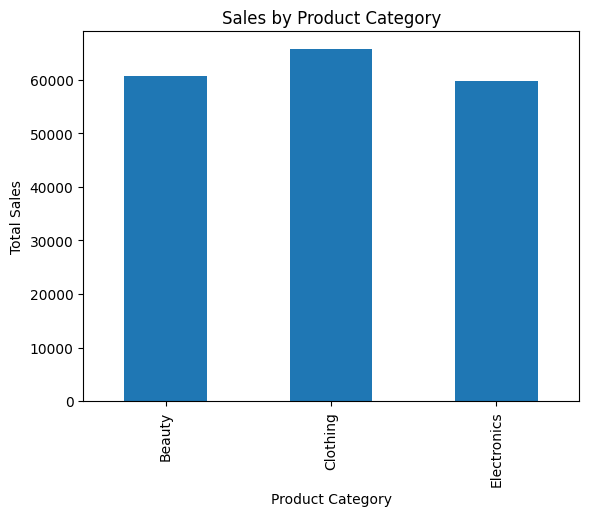

In [33]:
category = df.groupby("Product Category")["Total Amount"].sum()
category.plot(kind="bar")
plt.title("Sales by Product Category")             # used for Bar Chart
plt.xlabel("Product Category")
plt.ylabel("Total Sales")
plt.show()

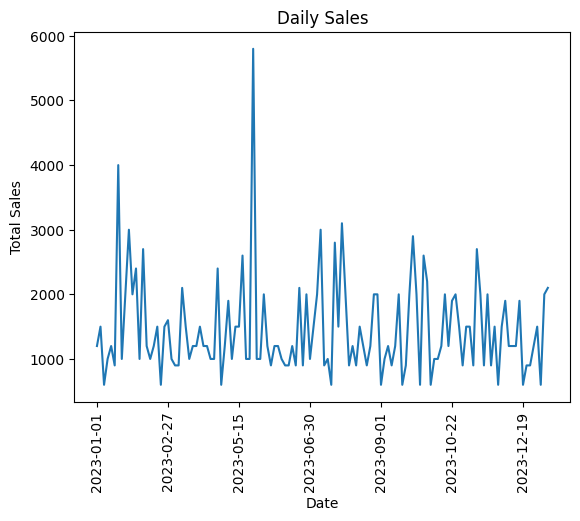

In [34]:
daily = df.groupby("Date")["Total Amount"].sum()
daily.plot(kind="line")
plt.title("Daily Sales")        #Used for Line chart
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.xticks(rotation=90)
plt.show()

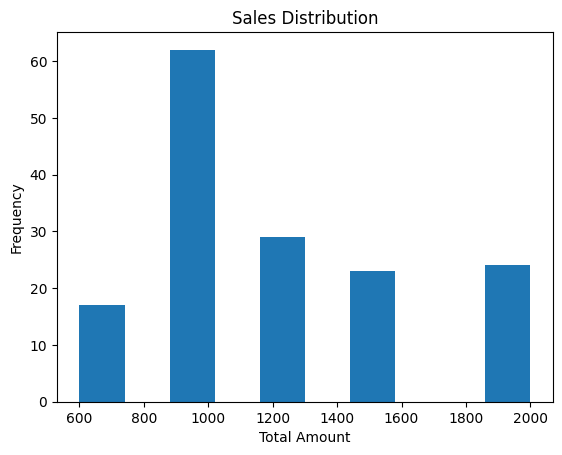

In [35]:
plt.hist(df["Total Amount"], bins=10)
plt.title("Sales Distribution")
plt.xlabel("Total Amount")            #Used for the Histogram
plt.ylabel("Frequency")
plt.show()

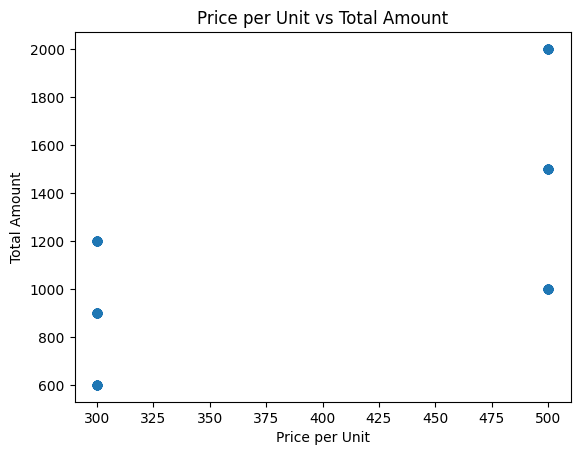

In [36]:
plt.scatter(df["Price per Unit"], df["Total Amount"])
plt.title("Price per Unit vs Total Amount")
plt.xlabel("Price per Unit")           #Used for Scatter plot
plt.ylabel("Total Amount")
plt.show()

In [37]:
df.to_csv("cleaned_retail_sales.csv", index=False)  #Saving the cleaning data

Report:
1. Electronics products generated high sales compared to other categories.
2. Customers purchasing more items generally had a higher total purchase amount.
3. Sales varied across different product categories.
4. Most transactions had moderate sales, while a few transactions had very high sales.
5. Removing missing values and duplicates improved the dataset quality.
6. The visualizations helped identify sales trends and customer purchasing behavior.